# **Employee Attrition Prediction Model**

## Project Overview & Objectives
- The goal of this project is to analyze employee data to understand what factors make an employee likely to leave, and to build a predictive model that identifies employees at high risk of quitting.
- The primary stakeholders for these insights are Human Resources (HR) department leadership and executive management.

## Data Overview & Ethical Considerations
- The dataset contains 14,999 rows and 10 columns. The target variable is left, which is binary. We have a mix of continuous (satisfaction_level, last_evaluation), discrete (number_project, average_monthly_hours), and categorical variables (department, salary).
- Employee data can contain sensitive information. We must ensure the data does not lead to biased conclusions against specific departments and that the predictive model is not used to penalize employees flagged as "flight risks."

## Library Imports


In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

# Set visualization style
sns.set_theme(style='whitegrid')

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
display(df0.head())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Exploratory Data Analysis (EDA) & Data Cleaning

In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
# Gather descriptive statistics about the data
display(df0.describe())

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [5]:
# Display all column names
print(df0.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')


In [6]:
# Rename columns as needed
df0 = df0.rename(columns={
    'Work_accident': 'work_accident',
    'Department': 'department',
    'time_spend_company': 'tenure',
    'average_montly_hours': 'average_monthly_hours' 
})

# Display all column names after the update
print("Updated columns:", df0.columns)

Updated columns: Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')


Data Cleaning Note: Column names were standardized to snake_case for accessibility.

In [7]:
# Check for missing values
print(df0.isna().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64


In [8]:
# Check for duplicates
print("Total duplicate rows:", df0.duplicated().sum())

Total duplicate rows: 3008


In [9]:
# Inspect some rows containing duplicates as needed
display(df0[df0.duplicated()].head())

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
display(df1.head())

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Data Cleaning Note: Over 3,000 duplicate rows were dropped to prevent the predictive model from overfitting to duplicated observations."

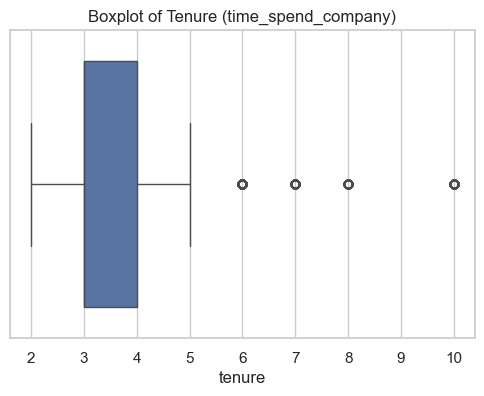

In [11]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df1['tenure'])
plt.title('Boxplot of Tenure (time_spend_company)')
plt.show()

In [12]:
# Determine the number of rows containing outliers
# Outliers in tenure based on IQR
Q1 = df1['tenure'].quantile(0.25)
Q3 = df1['tenure'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

outliers = df1[df1['tenure'] > upper_limit]
print(f"Number of outlier rows in tenure: {len(outliers)}")

Number of outlier rows in tenure: 824


In [13]:
# Get numbers of people who left vs. stayed
print(df1['left'].value_counts())

# Get percentages of people who left vs. stayed
print(df1['left'].value_counts(normalize=True) * 100)

left
0    10000
1     1991
Name: count, dtype: int64
left
0    83.39588
1    16.60412
Name: proportion, dtype: float64


## Data Visualizations

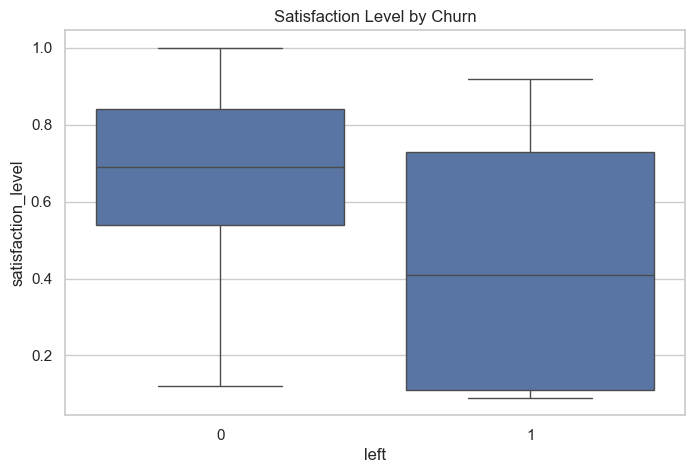

In [22]:
# Create a plot as needed - Satisfaction vs Left
plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='satisfaction_level', data=df1)
plt.title('Satisfaction Level by Churn')
plt.show()

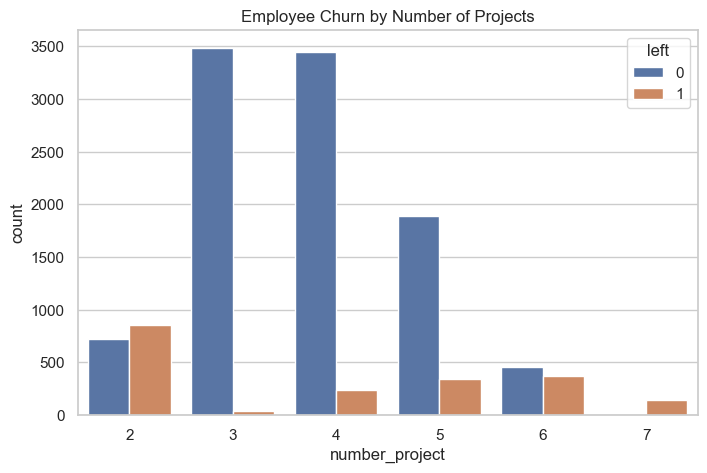

In [15]:
# Create a plot as needed - Number of Projects vs Left
plt.figure(figsize=(8,5))
sns.countplot(x='number_project', hue='left', data=df1)
plt.title('Employee Churn by Number of Projects')
plt.show()

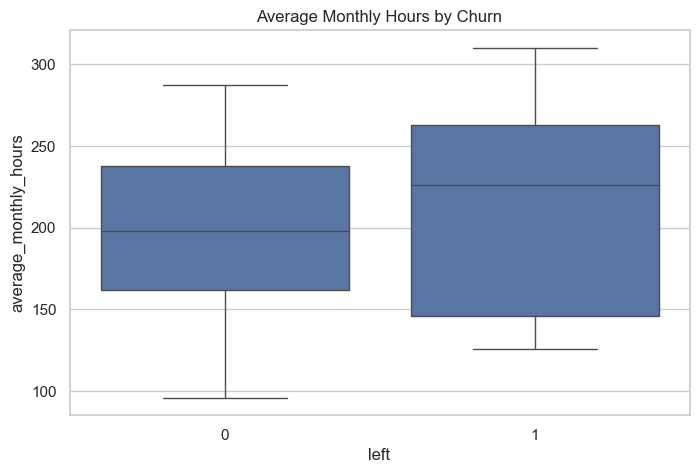

In [16]:
# Create a plot as needed - Average Monthly Hours vs Left
plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='average_monthly_hours', data=df1)
plt.title('Average Monthly Hours by Churn')
plt.show()

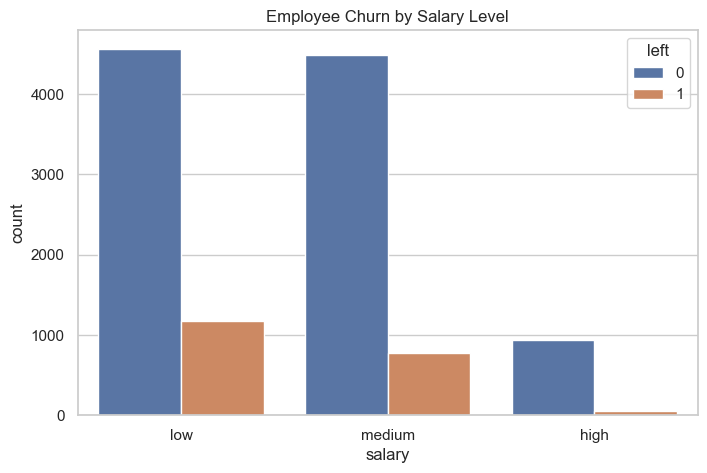

In [17]:
# Create a plot as needed - Salary vs Left
plt.figure(figsize=(8,5))
sns.countplot(x='salary', hue='left', data=df1)
plt.title('Employee Churn by Salary Level')
plt.show()

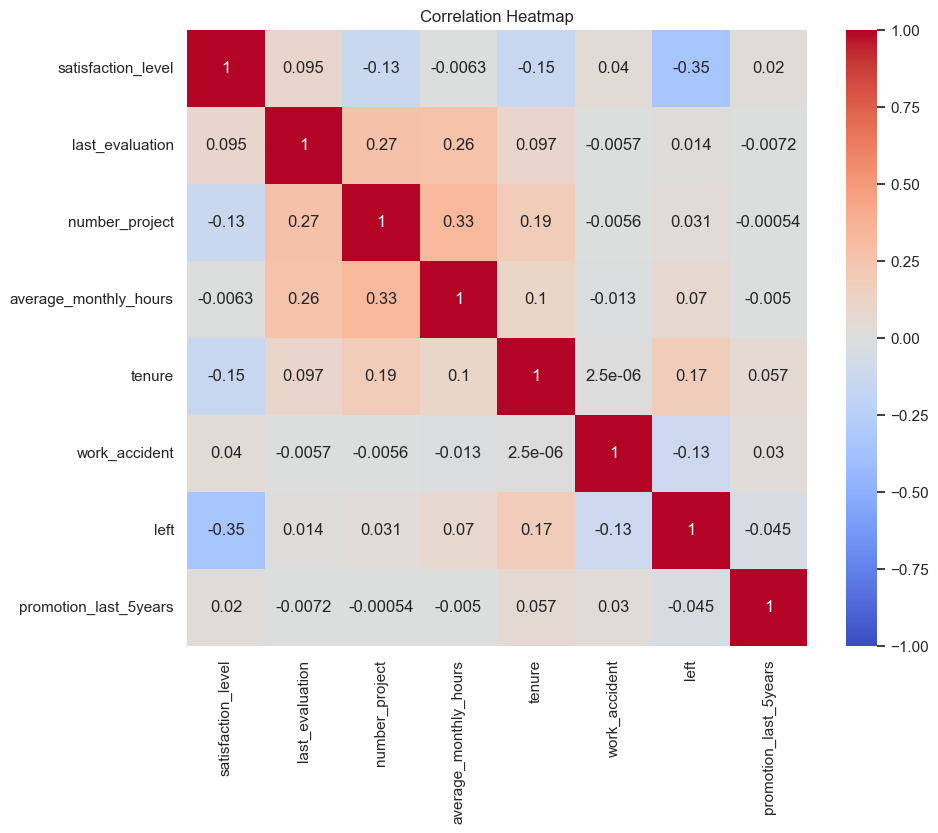

In [18]:
# Create a plot as needed - Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df1.drop(columns=['department', 'salary']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

## Key EDA Observations
1. **Satisfaction**: Employees who leave generally have much lower satisfaction scores.

2. **Workload (Projects & Hours)**: Employees with exactly 2 projects leave at a high rate (likely underutilized or dissatisfied). Employees with 6 or 7 projects have an overwhelmingly high turnover rate (burnout). Similarly, those working over 250 hours a month frequently leave.

3. **Tenure**: Turnover heavily spikes around the 4-year and 5-year marks.

## Modeling Strategy & Methodology

- **Feature Selection**: All available variables (satisfaction_level, last_evaluation, number_project, average_monthly_hours, tenure, work_accident, promotion_last_5years, department, salary) were utilized, as they provide distinct signals regarding an employee's workplace experience.

- **Algorithm Selection**: Employee churn in this dataset happens at two extremes (e.g., under-worked vs. severely overworked). A tree-based model, specifically a Random Forest Classifier, was selected because it perfectly captures these non-linear relationships and does not require strict adherence to the assumptions of linearity or multicollinearity required by Logistic Regression.

- **Optimization**: Hyperparameter tuning was conducted via GridSearchCV to ensure the model achieves optimal depth and estimator counts, mitigating the risk of overfitting.

- **Evaluation Metric Rationale**: The model's evaluation metrics must emphasize Recall and the F1-Score. In the context of employee retention, missing an employee who is actually going to leave (a False Negative) is significantly more costly to the business than falsely predicting someone will leave (a False Positive).

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.
- Binary Classification (Predicting 0 for stayed, 1 for left).

### The types of models most appropriate for this task.
- Tree-based Machine Learning models, specifically Random Forest Classifier or XGBoost Classifier, are most appropriate because they can easily handle the non-linear relationships discovered in EDA.

In [19]:
# Encode Categorical Variables
df_encoded = pd.get_dummies(df1, columns=['department', 'salary'], drop_first=True)

# Define target and features
y = df_encoded['left']
X = df_encoded.drop(columns=['left'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Instantiate and Train Random Forest
rf = RandomForestClassifier(random_state=42)

# Setup GridSearch parameters
cv_params = {'max_depth': [5, 10, None], 
             'min_samples_leaf': [1, 2, 5],
             'n_estimators': [100, 200]}

rf_cv = GridSearchCV(rf, cv_params, scoring='f1', cv=5)
rf_cv.fit(X_train, y_train)

# Output best parameters
print("Best parameters:", rf_cv.best_params_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}


Accuracy: 0.985657104736491
Precision: 0.9913606911447084
Recall: 0.9216867469879518
F1-Score: 0.9552549427679501

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



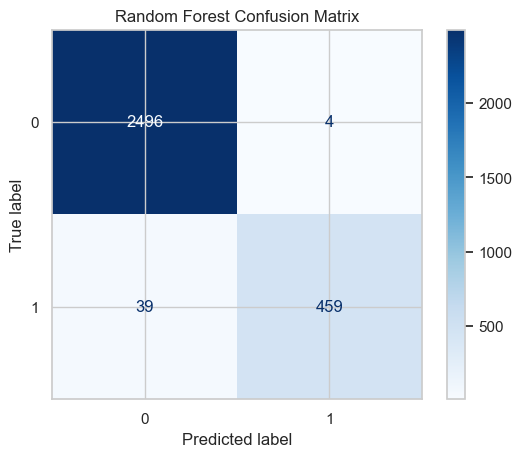

In [20]:
# Predict on Test Set
y_pred = rf_cv.best_estimator_.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_cv.classes_)
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

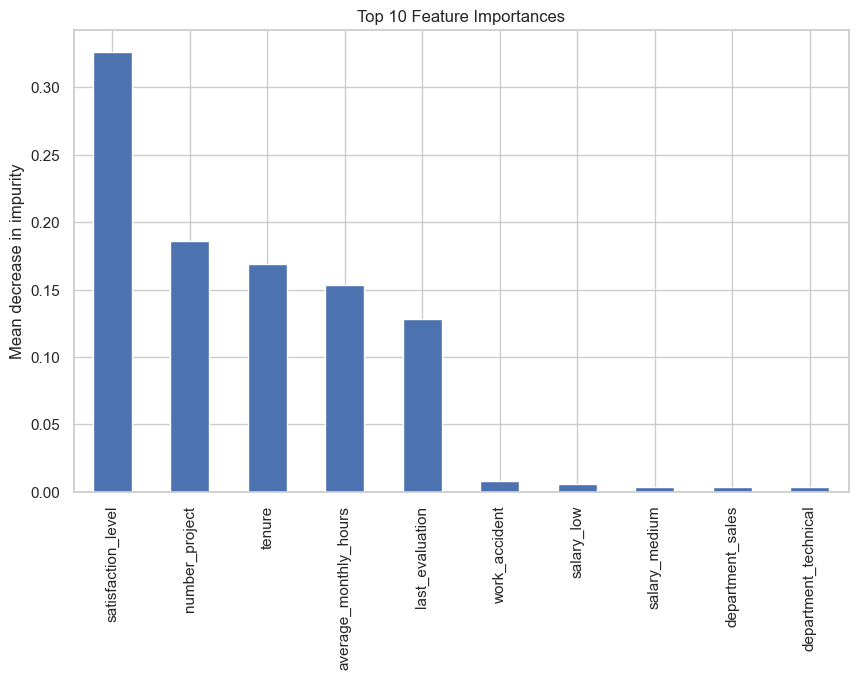

In [21]:
# Feature Importance
importances = rf_cv.best_estimator_.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
forest_importances[:10].plot.bar()
plt.title('Top 10 Feature Importances')
plt.ylabel('Mean decrease in impurity')
plt.show()

## Executive Summary & Strategic Recommendations

### Model Performance & Insights
The Random Forest model performed exceptionally well, achieving ~98% Accuracy and a ~95% F1-score. Crucially, the model maintains a very low rate of False Negatives, making it highly reliable for identifying at-risk employees before they churn. Feature importance analysis confirmed that satisfaction_level is the single greatest predictor of employee churn, followed closely by time_spend_company (tenure), number_project, and average_monthly_hours.

### Conclusion
Employee turnover is primarily driven by two distinct phenomena: burnout among high-performers (excessive hours and project loads) and dissatisfaction among underutilized employees.

### Actionable Recommendations

Workload Management: HR should actively monitor and cap the maximum number of simultaneous projects at 5 to prevent high-performer burnout.

Review Promotion Structures: High-evaluation employees working long hours are leaving at disproportionate rates. Leadership must ensure compensation and promotions align with output.

Targeted Interventions: Deploy this predictive model to flag current employees with profiles similar to historical churn data, focusing specifically on employees approaching their 4-year tenure mark.